# Boston Housing Price Prediction — Linear Regression using Deep Neural Network

**Problem Statement:** Implement Boston housing price prediction by Linear Regression using a Deep Neural Network. Use the Boston House Price dataset.

**Dataset:** Boston Housing Price dataset
> Dataset link: https://www.kaggle.com/datasets/altavish/boston-housing-dataset

**Model:** Deep Neural Network (DNN) — with Linear activation at output for regression


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Load and Explore the Dataset

**Column Descriptions:**

| Column | Description |
|--------|-------------|
| `CRIM` | Per-capita crime rate |
| `ZN` | Proportion of residential land |
| `INDUS` | Proportion of non-retail business acres |
| `CHAS` | Charles River dummy variable (1 if tract bounds river, else 0) |
| `NOX` | Nitric oxide concentration |
| `RM` | Average number of rooms per dwelling |
| `AGE` | Proportion of owner-occupied units built before 1940 |
| `DIS` | Distances to employment centres |
| `RAD` | Accessibility to radial highways |
| `TAX` | Property-tax rate |
| `PTRATIO` | Pupil-teacher ratio |
| `B` | 1000(Bk - 0.63)^2 where Bk is proportion of Black residents |
| `LSTAT` | % lower status of the population |
| **`MEDV`** | **Median home value (Target — in $1000s)** |

In [2]:
# Load the dataset
df = pd.read_csv('HousingData.csv')

# Standardise column names to uppercase (works for any CSV variant)
df.columns = df.columns.str.upper()

In [3]:
print("Shape:", df.shape)

Shape: (506, 14)


In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [5]:
# Basic statistics
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [7]:
# Fill missing values with column median 
df.fillna(df.median(), inplace=True)

## Step 3: Visualize Key Features

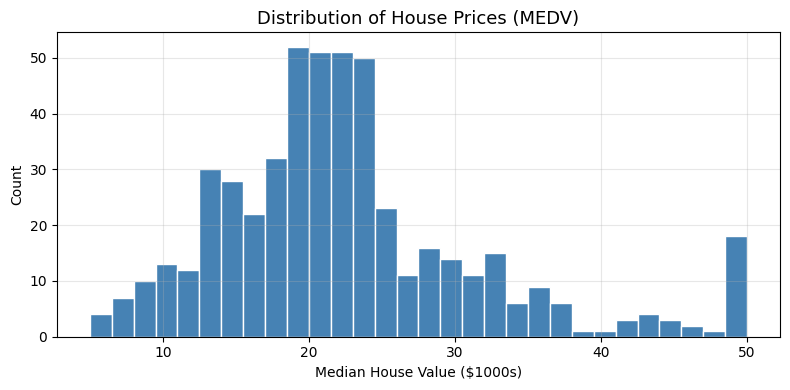

In [8]:
# Distribution of target variable — House Price (MEDV)
plt.figure(figsize=(8, 4))
plt.hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of House Prices (MEDV)', fontsize=13)
plt.xlabel('Median House Value ($1000s)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

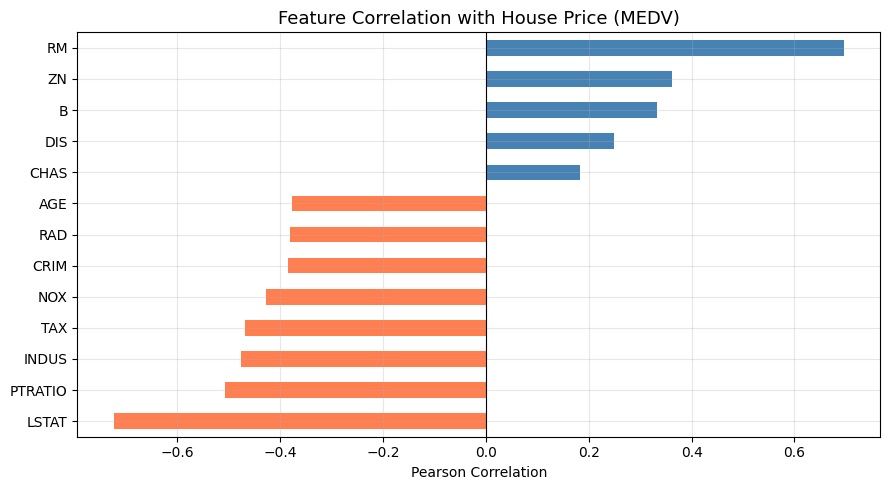

In [9]:
# Correlation of each feature with the target (MEDV)
correlations = df.corr()['MEDV'].drop('MEDV').sort_values()

plt.figure(figsize=(9, 5))
colors = ['coral' if c < 0 else 'steelblue' for c in correlations]
correlations.plot(kind='barh', color=colors)
plt.title('Feature Correlation with House Price (MEDV)', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

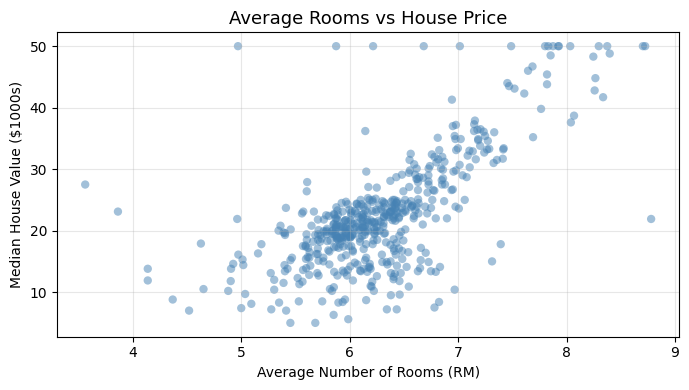

In [10]:
# Scatter plot: Rooms (RM) vs Price — strongest positive correlation
plt.figure(figsize=(7, 4))
plt.scatter(df['RM'], df['MEDV'], alpha=0.5, color='steelblue', edgecolors='none')
plt.title('Average Rooms vs House Price', fontsize=13)
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value ($1000s)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Preprocess the Data

### 4a. Separate Features and Target

In [11]:
# Features (X) and Target (y)
X = df.drop('MEDV', axis=1).values   # all columns except target
y = df['MEDV'].values                # target: median house value

print('Features shape:', X.shape)
print('Target  shape :', y.shape)

Features shape: (506, 13)
Target  shape : (506,)


### 4b. Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing  samples:", X_test.shape[0])

Training samples: 404
Testing  samples: 102


### 4c. Normalize Features (StandardScaler)

Neural networks train better when features are on the same scale.  
`StandardScaler` transforms each feature to have **mean = 0** and **std = 1**.

>  Fit the scaler **only on training data**, then apply (transform) it on both train and test.

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test  = scaler.transform(X_test)        # transform only on test

## Step 5: Build the DNN Model

We build a **Deep Neural Network** with:
- 3 hidden layers with `relu` activation → learns non-linear patterns
- 1 output layer with **linear activation** → for continuous value prediction (regression)

>  **Why linear output?**  
> In regression, we need the model to output any real number (house price), not a probability. Linear activation allows unbounded output.

>  **Architecture choice:** Wider layers (128 → 64 → 32) help the network learn richer feature combinations from the 13 housing features.

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [18]:
model = Sequential([
    # Hidden Layer 1 — wider to capture feature interactions
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),

    # Hidden Layer 2
    Dense(64, activation='relu'),

    # Hidden Layer 3
    Dense(32, activation='relu'),

    # Output Layer — linear for regression (predict a continuous value)
    Dense(1, activation='linear')
])

C:\Users\Admin\ml-env\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Compile: MSE loss is standard for regression problems
# lr=0.003 converges faster than 0.001 on this dataset
model.compile(optimizer=Adam(learning_rate=0.003), loss='mse', metrics=['mae'])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

In [21]:
history = model.fit( X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 434.1304 - mae: 18.5238 - val_loss: 88.2923 - val_mae: 7.1943
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 77.7588 - mae: 6.5023 - val_loss: 41.1627 - val_mae: 4.5291
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 23.1810 - mae: 3.5356 - val_loss: 34.5073 - val_mae: 3.9636
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 17.9615 - mae: 3.0633 - val_loss: 30.6924 - val_mae: 3.7826
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 15.9082 - mae: 2.9569 - val_loss: 26.1776 - val_mae: 3.5290
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 13.7845 - mae: 2.7057 - val_loss: 26.3841 - val_mae: 3.6016
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 13.0757 - mae: 2.6376 - val_loss: 23.7239 - val_mae: 3.4823
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 12.3087 - mae: 2.5904 - val_loss: 24.3460 - val_mae: 3.4631
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━

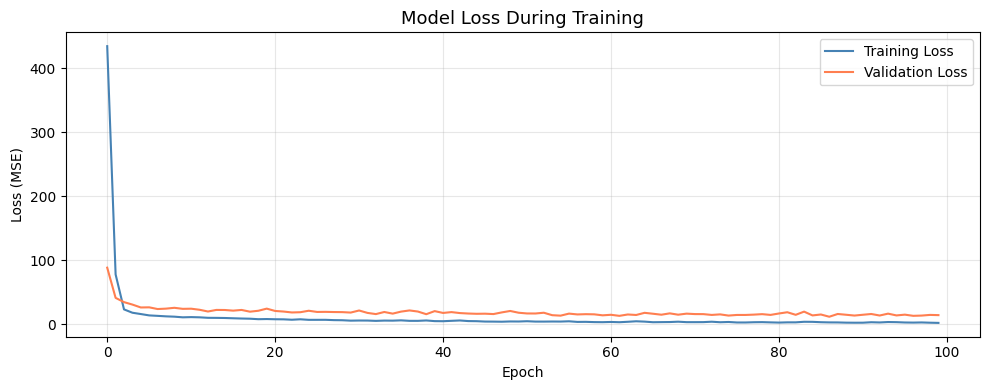

In [22]:
# Plot Training and Validation Loss (MSE)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral')
plt.title('Model Loss During Training', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Evaluate the Model

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
# Get predictions
y_pred = model.predict(X_test).flatten()   # flatten to 1D array

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [25]:
# Calculate evaluation metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

In [26]:
print(f"Mean Squared Error  (MSE) : {mse:.2f}")
print(f"Root Mean Sq. Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"R\u00b2 Score                  : {r2:.4f}")
print(f"\nR\u00b2 of {r2:.2%} means the model explains {r2:.2%} of the variance in house prices.")

Mean Squared Error  (MSE) : 13.13
Root Mean Sq. Error (RMSE): 3.62
Mean Absolute Error (MAE) : 2.12
R² Score                  : 0.8209

R² of 82.09% means the model explains 82.09% of the variance in house prices.


## Step 8: Visualize Predictions vs Actual

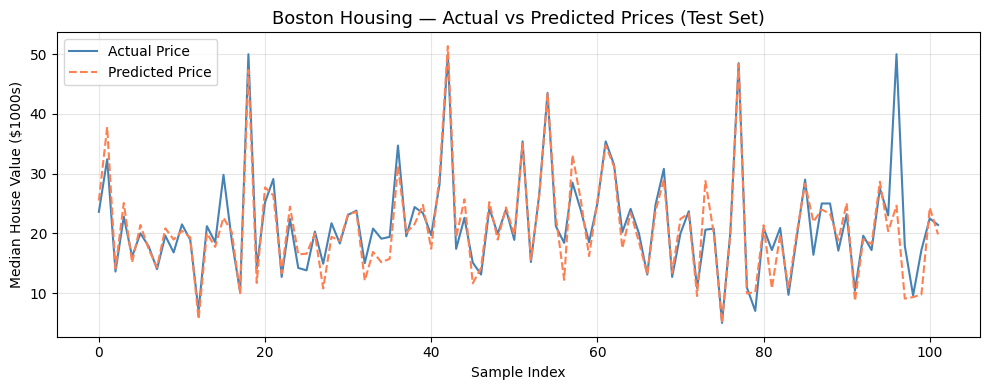

In [27]:
# Plot Actual vs Predicted house prices
plt.figure(figsize=(10, 4))
plt.plot(y_test,  label='Actual Price',    color='steelblue', linewidth=1.5)
plt.plot(y_pred,  label='Predicted Price', color='coral',     linewidth=1.5, linestyle='--')
plt.title('Boston Housing — Actual vs Predicted Prices (Test Set)', fontsize=13)
plt.xlabel('Sample Index')
plt.ylabel('Median House Value ($1000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

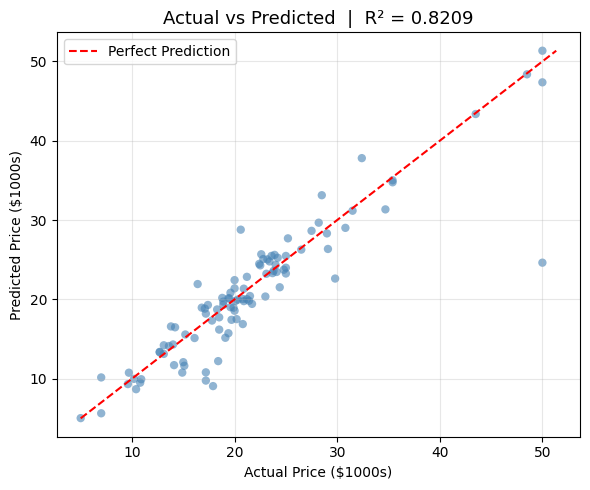

In [28]:
# Scatter plot: Actual vs Predicted — ideal model lies on the diagonal
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='none')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')

plt.title(f'Actual vs Predicted  |  R\u00b2 = {r2:.4f}', fontsize=13)
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()